# UAS Kecerdasan Buatan

## Penjadwalan Mata Kuliah Menggunakan Genetic Algorithm

**Nama:** M. Sultan Ismail

**NIM:** 24146091

Program ini bertujuan menghasilkan jadwal ujian menggunakan Algoritma Genetika.

In [14]:
import random
import copy
import csv
import matplotlib.pyplot as plt

In [15]:
courses = [
    ("AI", "DosenA"),
    ("ML", "DosenB"),
    ("DB", "DosenC"),
    ("CN", "DosenD"),
    ("SE", "DosenE"),
    ("OS", "DosenF"),
    ("IR", "DosenA"),
    ("NLP", "DosenB"),
    ("CV", "DosenC"),
    ("IoT", "DosenD"),
    ("CyberSec", "DosenF"),
    ("BigData", "DosenA"),
    ("DL", "DosenB"),
    ("NoSQL", "DosenC"),
    ("Cloud", "DosenD"),
    ("UX", "DosenE"),
    ("SecEng", "DosenF"),
    ("Agile", "DosenA"),
    ("RL", "DosenB"),
    ("ETL", "DosenC"),
    ("DevOps", "DosenD"),
    ("GameDev", "DosenE"),
    ("Blockchain", "DosenF"),
    ("DataMining", "DosenA")
]

rooms = ["R1", "R2", "R3", "R4"]

timeslots = [
    "Senin-08",
    "Senin-10",
    "Senin-13",
    "Selasa-08",
    "Selasa-10",
    "Selasa-13",
    "Rabu-08",
    "Rabu-10",
    "Rabu-13",
    "Kamis-08",
    "Kamis-10",
    "Kamis-13"
]

In [16]:
def create_individual():
    
    individual = []

    for course, lecturer in courses:

        gene = {
            "course": course,
            "lecturer": lecturer,
            "room": random.choice(rooms),
            "timeslot": random.choice(timeslots)
        }

        individual.append(gene)

    return individual


def create_population(population_size):

    return [
        create_individual()
        for _ in range(population_size)
    ]

In [17]:
def fitness(individual):
    
    conflicts = 0

    room_schedule = {}
    lecturer_schedule = {}
    lecturer_day = {}

    for gene in individual:

        room = gene["room"]
        timeslot = gene["timeslot"]
        lecturer = gene["lecturer"]

        day = timeslot.split("-")[0]

        if (room, timeslot) in room_schedule:
            conflicts += 1
        else:
            room_schedule[(room, timeslot)] = True

        if (lecturer, timeslot) in lecturer_schedule:
            conflicts += 1
        else:
            lecturer_schedule[(lecturer, timeslot)] = True

        if (lecturer, day) in lecturer_day:
            conflicts += 1
        else:
            lecturer_day[(lecturer, day)] = True

    fitness_score = 100 / (1 + conflicts)

    return fitness_score, conflicts

In [18]:
def selection(population):
    tournament = random.sample(population, 3)
    tournament.sort(key=lambda ind: fitness(ind)[0], reverse=True)
    return copy.deepcopy(tournament[0])

In [19]:
POPULATION_SIZE = 60
GENERATIONS = 100
CROSSOVER_RATE = 0.85
MUTATION_RATE = 0.20
ELITE_SIZE = 2

In [20]:
def crossover(parent1, parent2):
    
    if random.random() > CROSSOVER_RATE:
        return copy.deepcopy(parent1), copy.deepcopy(parent2)

    point = random.randint(1, len(parent1) - 2)

    child1 = copy.deepcopy(parent1[:point] + parent2[point:])
    child2 = copy.deepcopy(parent2[:point] + parent1[point:])

    return child1, child2

In [21]:
def mutation(individual):
    
    for gene in individual:

        if random.random() < MUTATION_RATE:

            if random.random() < 0.5:
                gene["room"] = random.choice(rooms)
            else:
                gene["timeslot"] = random.choice(timeslots)

    return individual

In [22]:
def run_genetic_algorithm():
    
    population = create_population(POPULATION_SIZE)

    best_history = []
    avg_history = []

    best_individual = None

    for generation in range(GENERATIONS):

        population.sort(
            key=lambda ind: fitness(ind)[0],
            reverse=True
        )

        best_individual = copy.deepcopy(population[0])

        max_fit = fitness(best_individual)[0]

        avg_fit = sum(
            fitness(ind)[0]
            for ind in population
        ) / POPULATION_SIZE

        best_history.append(max_fit)
        avg_history.append(avg_fit)

        print(
            f"Generasi {generation+1:3} | "
            f"Max = {max_fit:.2f} | "
            f"Avg = {avg_fit:.2f}"
        )

        if max_fit == 100:
            print("\nSolusi optimal ditemukan!")
            break

        new_population = [
            copy.deepcopy(ind)
            for ind in population[:ELITE_SIZE]
        ]

        while len(new_population) < POPULATION_SIZE:

            parent1 = selection(population)
            parent2 = selection(population)

            child1, child2 = crossover(parent1, parent2)

            child1 = mutation(child1)
            child2 = mutation(child2)

            new_population.append(child1)

            if len(new_population) < POPULATION_SIZE:
                new_population.append(child2)

        population = new_population

    return best_individual, best_history, avg_history

In [23]:
best_individual, max_history, avg_history = run_genetic_algorithm()

fitness_score, konflik = fitness(best_individual)

print("=" * 50)
print("HASIL AKHIR")
print("=" * 50)
print(f"Fitness Terbaik : {fitness_score:.2f}")
print(f"Jumlah Konflik  : {konflik}")

Generasi   1 | Max = 11.11 | Avg = 6.08
Generasi   2 | Max = 14.29 | Avg = 6.92
Generasi   3 | Max = 14.29 | Avg = 7.39
Generasi   4 | Max = 14.29 | Avg = 7.78
Generasi   5 | Max = 14.29 | Avg = 7.92
Generasi   6 | Max = 14.29 | Avg = 8.30
Generasi   7 | Max = 14.29 | Avg = 8.00
Generasi   8 | Max = 16.67 | Avg = 8.19
Generasi   9 | Max = 16.67 | Avg = 8.43
Generasi  10 | Max = 16.67 | Avg = 8.84
Generasi  11 | Max = 16.67 | Avg = 8.62
Generasi  12 | Max = 16.67 | Avg = 8.36
Generasi  13 | Max = 16.67 | Avg = 8.32
Generasi  14 | Max = 16.67 | Avg = 8.25
Generasi  15 | Max = 16.67 | Avg = 8.72
Generasi  16 | Max = 16.67 | Avg = 9.23
Generasi  17 | Max = 16.67 | Avg = 9.39
Generasi  18 | Max = 16.67 | Avg = 9.19
Generasi  19 | Max = 16.67 | Avg = 9.35
Generasi  20 | Max = 16.67 | Avg = 9.25
Generasi  21 | Max = 16.67 | Avg = 9.01
Generasi  22 | Max = 16.67 | Avg = 9.16
Generasi  23 | Max = 20.00 | Avg = 9.52
Generasi  24 | Max = 20.00 | Avg = 9.78
Generasi  25 | Max = 20.00 | Avg = 9.87


In [24]:
print("=" * 80)
print("JADWAL TERBAIK HASIL GENETIC ALGORITHM")
print("=" * 80)

print(f"{'No':<3} {'Mata Kuliah':<15} {'Dosen':<10} {'Ruang':<6} {'Waktu':<12}")
print("-" * 80)

for i, gene in enumerate(best_individual, start=1):
    print(
        f"{i:<3} "
        f"{gene['course']:<15} "
        f"{gene['lecturer']:<10} "
        f"{gene['room']:<6} "
        f"{gene['timeslot']:<12}"
    )

JADWAL TERBAIK HASIL GENETIC ALGORITHM
No  Mata Kuliah     Dosen      Ruang  Waktu       
--------------------------------------------------------------------------------
1   AI              DosenA     R3     Kamis-08    
2   ML              DosenB     R3     Selasa-10   
3   DB              DosenC     R1     Selasa-10   
4   CN              DosenD     R3     Selasa-08   
5   SE              DosenE     R1     Rabu-08     
6   OS              DosenF     R2     Senin-13    
7   IR              DosenA     R4     Rabu-13     
8   NLP             DosenB     R1     Senin-10    
9   CV              DosenC     R3     Rabu-13     
10  IoT             DosenD     R3     Rabu-08     
11  CyberSec        DosenF     R4     Kamis-08    
12  BigData         DosenA     R1     Senin-08    
13  DL              DosenB     R4     Rabu-10     
14  NoSQL           DosenC     R1     Kamis-13    
15  Cloud           DosenD     R1     Kamis-10    
16  UX              DosenE     R4     Senin-08    
17  SecEng   

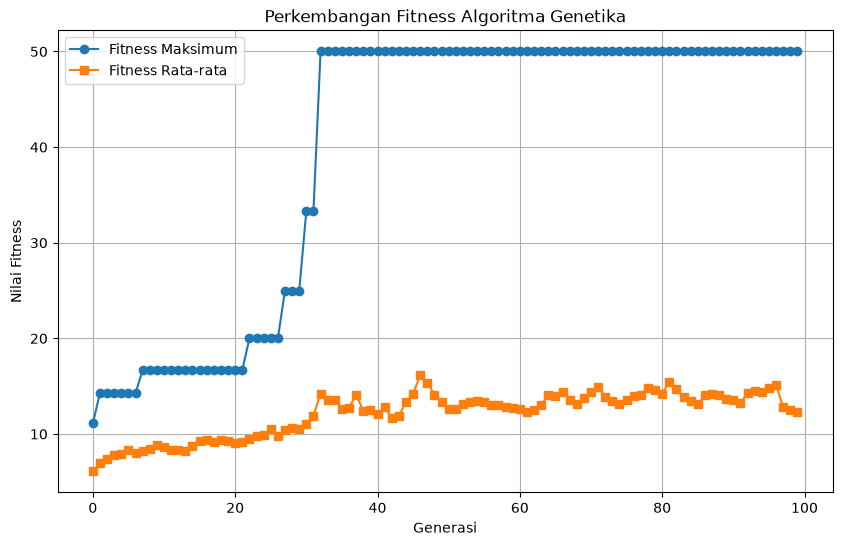

In [25]:
plt.figure(figsize=(10, 6))

plt.plot(max_history, label="Fitness Maksimum", marker="o")
plt.plot(avg_history, label="Fitness Rata-rata", marker="s")

plt.title("Perkembangan Fitness Algoritma Genetika")
plt.xlabel("Generasi")
plt.ylabel("Nilai Fitness")

plt.grid(True)
plt.legend()

plt.show()